# Despeckling via Median Filter

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.signal import detrend

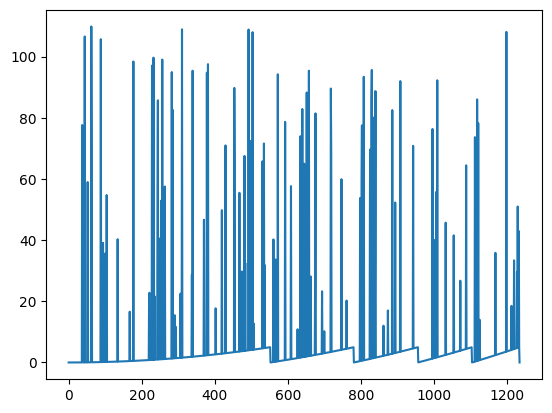

In [ ]:
# DEMO 1: Median Filtering & Despeckling

pnts = 1234
signal = np.mod(np.linspace(0,5,pnts)**2,5)

p = int(0.1*pnts)
spiketimes = np.random.randint(0,pnts,p)

signal[spiketimes] = np.random.rand(p)*100 + 10

plt.plot(signal)
plt.show()

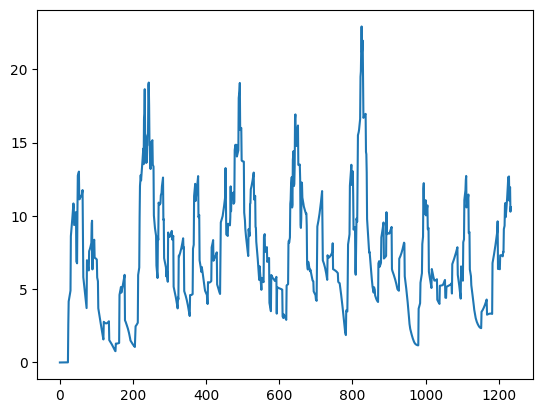

In [21]:
# Try mean-filtering

k = 15

for i in range(pnts):
  signal[i] = np.mean(signal[np.max((0, i-k)):np.min((pnts,i+k))])

plt.plot(signal)

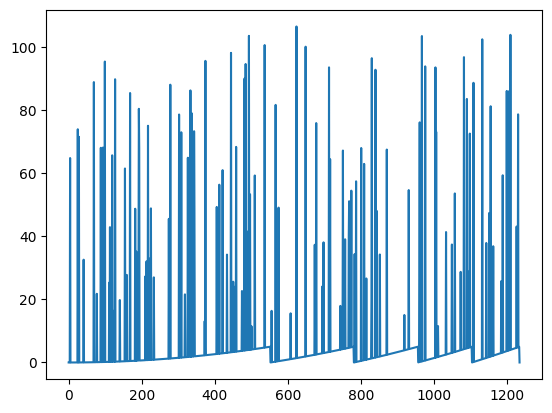

In [ ]:
# DEMO 2: Threshold Based Spike Detection & Local Median Replacement

pnts = 1234
signal = np.mod(np.linspace(0,5,pnts)**2,5)

p = int(0.1*pnts)
spiketimes = np.random.randint(0,pnts,p)

signal[spiketimes] = np.random.rand(p)*100 + 10

plt.plot(signal)
plt.show()

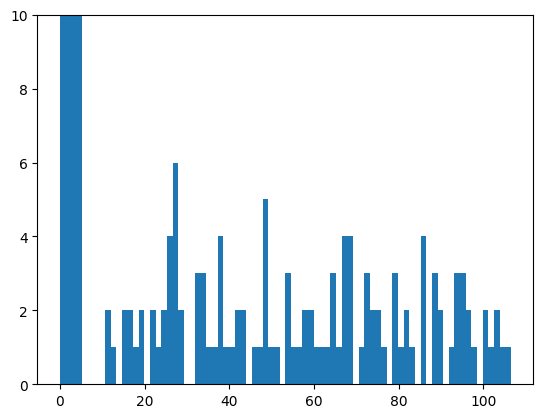

In [23]:
# Empirically define a threshold for spike

plt.hist(signal, 80)
plt.ylim([0,10])
plt.show()

In [24]:
thresh = 8

# find all supra-threshold data indices

supra_threshold_idx = np.where(signal>thresh)[0]

100 * len(supra_threshold_idx) / pnts

9.724473257698541

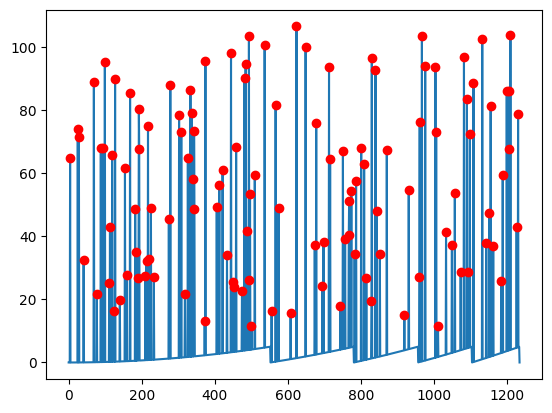

In [25]:
plt.plot(signal)
plt.plot(supra_threshold_idx, signal[supra_threshold_idx], 'ro')
plt.show()

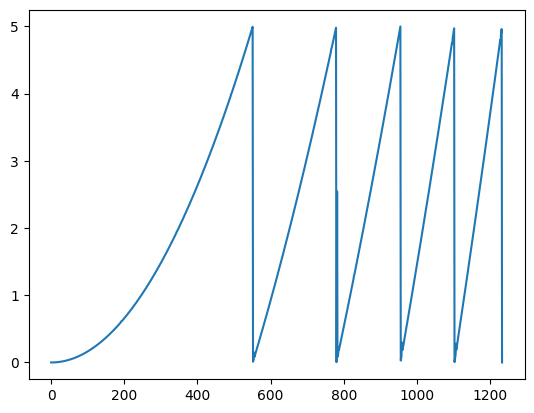

In [26]:
k = 7

for i in supra_threshold_idx:
  lowbnd = np.max((0,i-k))
  uppbnd = np.min((pnts,i+k))
  signal[i] = np.median(signal[lowbnd:uppbnd])

plt.plot(signal)
plt.show()